In [153]:
import matplotlib.pyplot as plt
import numpy as np

# Normal image

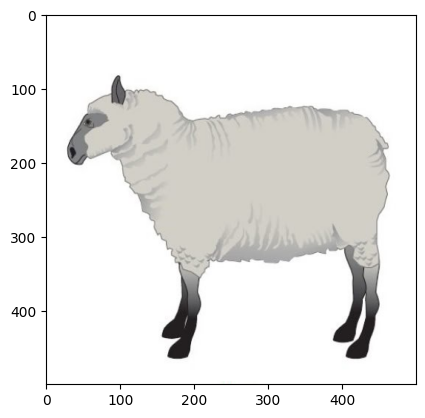

In [154]:
img = plt.imread('sheep.jpg')
plt.imshow(img)

# Converting image to vectors

In [155]:
def array_to_vectors(img: np.ndarray):
    y_range, x_range, _ = img.shape
    x_o, y_o = x_range // 2, y_range // 2
    return [np.array([i - x_o, j - y_o]) for i in range(x_range) for j in range(y_range)]

def vectors_to_array(vectors: list[np.ndarray], original: np.ndarray):
    y_range, x_range, _ = original.shape
    x_edge = max(vectors, key=lambda x: abs(x[0]))
    y_edge = max(vectors, key=lambda x: abs(x[1]))
    new_x_range = int((abs(x_edge[0]) + 1) * 2)
    new_y_range = int((abs(y_edge[1]) + 1) * 2)
    print(new_x_range)
    print(new_y_range)
    x_o, y_o = new_x_range // 2, new_y_range // 2
    image = np.ones((new_y_range, new_x_range, 3), dtype=np.uint8) * 255
    for i, vec in enumerate(vectors):
        x = int(vec[0]) + x_o
        y = int(vec[1]) + y_o
        if 0 <= x < new_x_range and 0 <= y < new_y_range:
            #print(y)
            #print(x)
            #print(i%y_range)
            #print(i//y_range)
            image[y, x] = original[i%y_range, i//y_range]

    return image.astype(np.uint8)

# Testing converters

502
502


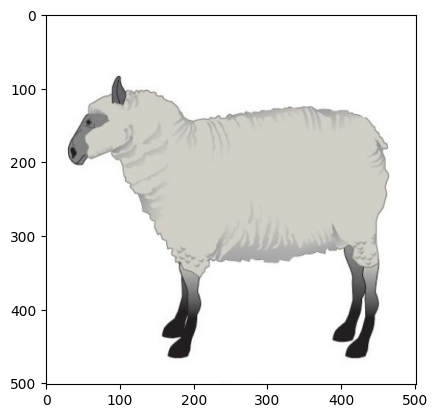

In [156]:
vecs = array_to_vectors(img)
rebuilt_img = vectors_to_array(vecs, img)
#plt.imshow(rebuilt_img)

plt.imshow(rebuilt_img)

In [157]:
print(img.dtype)
print(rebuilt_img.dtype)

uint8
uint8


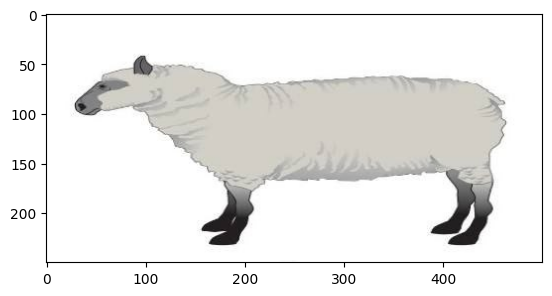

In [158]:
scaled_img = plt.imread('scaled_sheep.jpg')
plt.imshow(scaled_img)

502
252


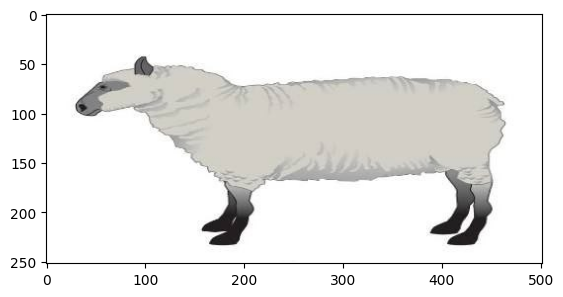

In [159]:
vecs = array_to_vectors(scaled_img)
rebuilt_img = vectors_to_array(vecs, scaled_img)
plt.imshow(rebuilt_img)

# Scaled image 

In [160]:
def shift_matrix(kx, ky):
    return np.array([[1/kx, 0],[0, 1/ky]])

502
502


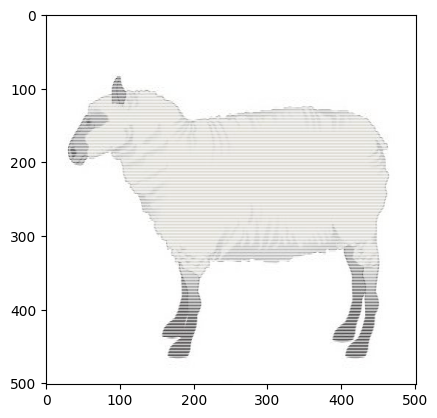

In [161]:
new_vecs = [shift_matrix(1, 0.5) @ v for v in vecs] 
rebuilt_img = vectors_to_array(new_vecs, scaled_img)
plt.imshow(rebuilt_img)

# Shear

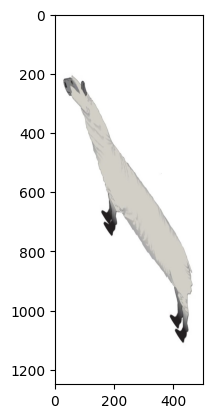

In [162]:
img = plt.imread('sheared_sheep.jpg')
plt.imshow(img)

In [163]:
def vertical_shear(b):
    return np.array([[1, 0], [b, 1]])

502
2000


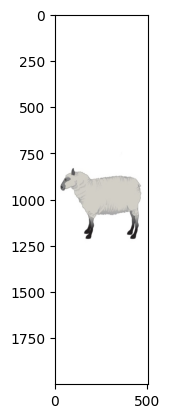

In [164]:
vecs = array_to_vectors(img)
new_vecs = [vertical_shear(-1.5) @ v for v in vecs]
rebuilt_img = vectors_to_array(new_vecs, img)
plt.imshow(rebuilt_img)

# Translation

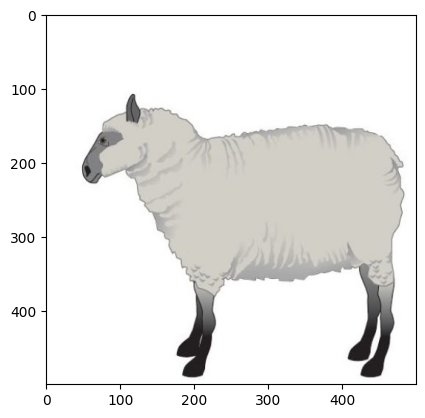

In [165]:
img = plt.imread('translated_sheep.jpg')
plt.imshow(img)

In [166]:
def translation(x, y, vecs):
    new_vecs = [v + np.array([x, y]) for v in vecs]
    return new_vecs[:-1] + [vecs[-1]]  # saving the size

542
562


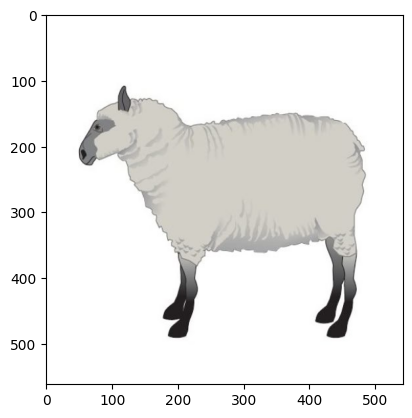

In [167]:
vecs = array_to_vectors(img)
new_vecs = translation(-20, -30, vecs)
rebuilt_img = vectors_to_array(new_vecs, img)
plt.imshow(rebuilt_img)

# Rotation

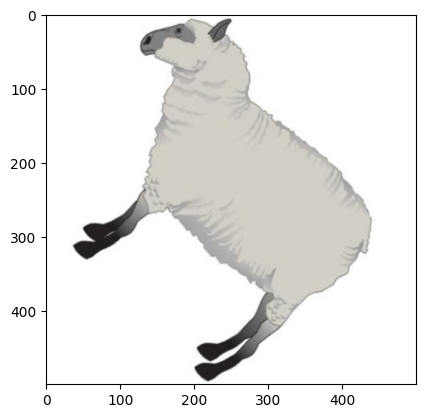

In [168]:
img = plt.imread('rotated_sheep.jpg')
plt.imshow(img)

In [169]:
def rotate(theta):
    return np.array([
        [np.cos(theta), np.sin(theta)],
        [-np.sin(theta), np.cos(theta)]])

709
707


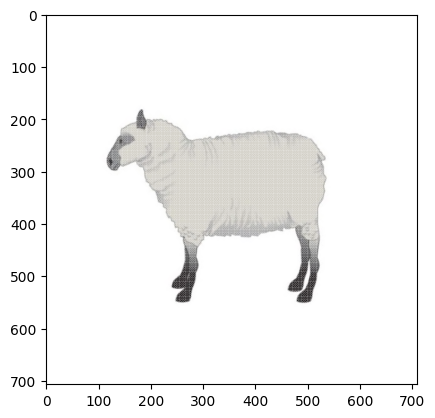

In [ ]:
vecs = array_to_vectors(img)
new_vecs = [rotate(np.pi / 4) @ v for v in vecs]
rebuilt_img = vectors_to_array(new_vecs, img)
plt.imshow(rebuilt_img)

# Mirroring

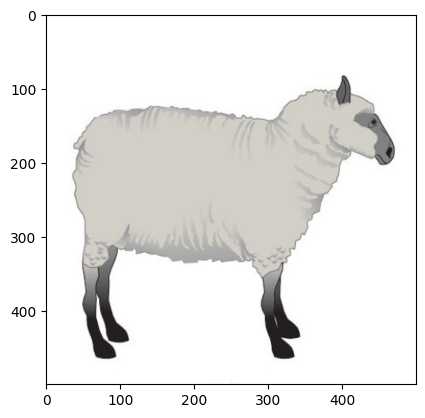

In [174]:
img = plt.imread('mirrored_sheep.jpg')
plt.imshow(img)

In [175]:
mirror = np.array([[-1, 0], [0,1]])

502
502


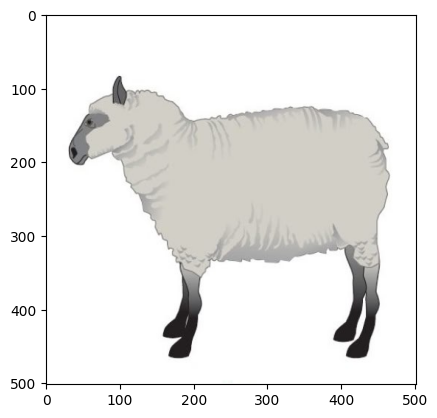

In [176]:
vecs = array_to_vectors(img)
new_vecs = [mirror @ v for v in vecs]
rebuilt_img = vectors_to_array(new_vecs, img)
plt.imshow(rebuilt_img)